# UPD Course Syllabi RAG

## Step 1 - Retrieve UPD Math Syllabi

In [20]:
#Import all packages

import os
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import tiktoken
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEndpointEmbeddings, HuggingFaceEndpoint, ChatHuggingFace
from langchain_together import ChatTogether
from langchain_pinecone import PineconeVectorStore
from langchain_huggingface import HuggingFaceEndpoint
from langchain_core.runnables import RunnablePassthrough
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
import json
from IPython.display import display, Markdown

In [ ]:
url = "https://math.upd.edu.ph/courses/undergraduate-courses"
folder = "UPD Math Syllabi"

if not os.path.exists(folder):
    os.makedirs(folder)

# 1. Get the page content
print("Fetching page...")
response = requests.get(url, timeout=10)
soup = BeautifulSoup(response.text, 'html.parser')

# 2. Find all <a> tags where the text contains "Syllabus"
syllabus_links = soup.find_all('a', string=lambda text: text and "Syllabus" in text)

print(f"Found {len(syllabus_links)} syllabi. Starting download...")

for link in syllabus_links:
    pdf_url = link.get('href')
    # Use the link text (e.g., "Math 2 Syllabus") as the filename
    file_name = link.text.strip().replace(" ", "_").replace("/", "-") + ".pdf"
    file_path = os.path.join(folder, file_name)
    
    try:
        # 3. Download the binary content of the PDF
        pdf_res = requests.get(pdf_url, timeout=20)
        if pdf_res.status_code == 200:
            with open(file_path, 'wb') as f:
                f.write(pdf_res.content)
            print(f"Successfully saved: {file_name}")
    except Exception as e:
        print(f"Failed to download {file_name}: {e}")

print("\nTask complete!")

Fetching page...
Found 33 syllabi. Starting download...
Successfully saved: Math_2_Syllabus.pdf
Successfully saved: Math_10_Syllabus.pdf
Successfully saved: Math_20_Syllabus.pdf
Successfully saved: Math_21_Syllabus.pdf
Successfully saved: Math_22_Syllabus.pdf
Successfully saved: Math_23_Syllabus.pdf
Successfully saved: Math_30_Syllabus.pdf
Successfully saved: Math_40_Syllabus.pdf
Successfully saved: Math_108_Syllabus.pdf
Successfully saved: Math_110.1_Syllabus.pdf
Successfully saved: Math_110.2_Syllabus.pdf
Successfully saved: Math_110.3_Syllabus.pdf
Successfully saved: Math_117_Syllabus.pdf
Successfully saved: Math_122_Syllabus.pdf
Successfully saved: Math_123.1_Syllabus.pdf
Successfully saved: Math_123.2_Syllabus.pdf
Successfully saved: Math_126_Syllabus.pdf
Successfully saved: Math_128_Syllabus.pdf
Successfully saved: Math_133_Syllabus.pdf
Successfully saved: Math_140_Syllabus.pdf
Successfully saved: Math_142_Syllabus.pdf
Successfully saved: Math_146_Syllabus.pdf
Successfully saved:

## Step 2 - Chunking

After having retrieved the math course syllabi we then use *RecursiveCharacterTextSplitter* to split the documents into chunks by recursively splitting text using separators, starting at paragraphs, then sentences, then words thereby ensuring semantic coherence. 

Additionally, we display a histogram of the number of tokens in each document before chunking and then the number of tokens in each chunk.  

Histogram saved as token_distribution.png


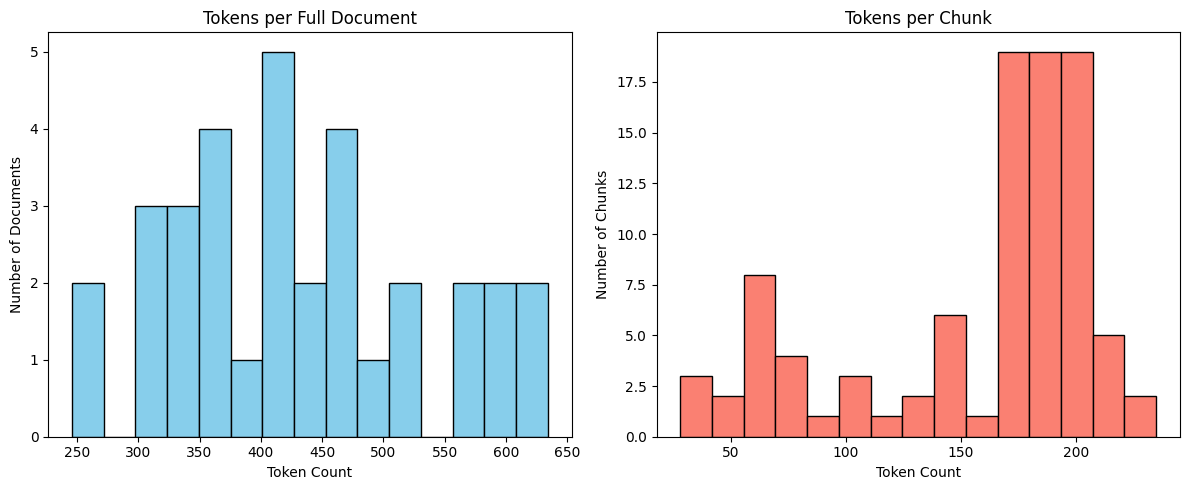

In [ ]:
# 1. Setup
path = "./UPD Math Syllabi"
tokenizer = tiktoken.get_encoding("cl100k_base")

def count_tokens(text):
    return len(tokenizer.encode(text))

# 2. Load and Count Full Documents
doc_counts = []
all_docs = []
for file in os.listdir(path):
    if file.endswith(".pdf"):
        loader = PyPDFLoader(os.path.join(path, file))
        data = loader.load()
        full_text = " ".join([d.page_content for d in data])
        doc_counts.append(count_tokens(full_text))
        all_docs.extend(data)

# 3. Chunk and Count Chunks
splitter = RecursiveCharacterTextSplitter(
    chunk_size=800, 
    chunk_overlap=80,
    separators=["\n\n", "\n", ". "]
)
chunks = splitter.split_documents(all_docs)
chunk_counts = [count_tokens(c.page_content) for c in chunks]

# 4. Plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Document Histogram
ax[0].hist(doc_counts, bins=15, color='skyblue', edgecolor='black')
ax[0].set_title('Tokens per Full Document')
ax[0].set_xlabel('Token Count')
ax[0].set_ylabel('Number of Documents')

# Chunk Histogram
ax[1].hist(chunk_counts, bins=15, color='salmon', edgecolor='black')
ax[1].set_title('Tokens per Chunk')
ax[1].set_xlabel('Token Count')
ax[1].set_ylabel('Number of Chunks')

plt.tight_layout()
plt.savefig("token_distribution.png")
print("Histogram saved as token_distribution.png")

## Step 3 - Embedding using BGE-M3

We will embed the chunks using BGE-M3 (through the HuggingFace API) an open source embedding model which supports both dense and sparse retrieval. 

Below we define the embedding model and test its functionality.

In [ ]:
load_dotenv()

embeddings = HuggingFaceEndpointEmbeddings(
    model="BAAI/bge-m3",
    huggingfacehub_api_token=os.getenv("HUGGINGFACE_API_TOKEN")
)

# Added a basic 'try-except' for cleaner debugging
try:
    test_vector = embeddings.embed_query("What are the math courses in UP Diliman?")
    print(f"Success! Vector Length: {len(test_vector)}")
except Exception as e:
    print(f"Connection Error: {e}")
    print("Tip: Check if your Hugging Face token is 'Read' or 'Write' type.")

d:\Program Files\AI Personal Projects\langchainproject\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Success! Vector Length: 1024


Below, we embed all the chunks then upload the embedded chunks with their corresponding chunks to Pinecone for safekeeping.

In [ ]:
load_dotenv()

os.environ['PINECONE_API_KEY'] = os.getenv("PINECONE_API_KEY")

#Upload to Pinecone
index_name = "updcoursessyllabindex"

print("Uploading chunks to Pinecone... this may take a minute.")

vectorstore = PineconeVectorStore.from_documents(
    documents=chunks, 
    embedding=embeddings, 
    index_name=index_name
)

print("Upload Complete! Your syllabi are now stored in the cloud.")

Uploading chunks to Pinecone... this may take a minute.
Upload Complete! Your syllabi are now stored in the cloud.


In [4]:
#Below we test out the retriever to make sure everything is working as expected.

load_dotenv()
os.environ['PINECONE_API_KEY'] = os.getenv("PINECONE_API_KEY")

# 1. Re-initialize the embedding "Pointer" (Cloud-based)
embeddings = HuggingFaceEndpointEmbeddings(
    model="BAAI/bge-m3",
    huggingfacehub_api_token=os.getenv("HUGGINGFACE_API_TOKEN")
)

# 2. Connect to the existing Pinecone Index
index_name = "updcoursessyllabindex" 

vectorstore = PineconeVectorStore.from_existing_index(
    index_name=index_name, 
    embedding=embeddings
)

# 3. Create the Retriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

# Test Query
query = "What are the prerequisites for Math 21?"
docs = retriever.invoke(query)

for i, doc in enumerate(docs):
    print(f"\n--- Result {i+1} ---")
    print(doc.page_content[:200] + "...")


--- Result 1 ---
INSTITUTE OF MATHEMATICS
College of Science
University of the Philippines Diliman
Math 21 Course Syllabus
A. Course Catalogue Description
Course Number Math 21
Course Title Elementary Analysis I
Cours...

--- Result 2 ---
INSTITUTE OF MATHEMATICS
College of Science
University of the Philippines Diliman
Math 22 Course Syllabus
A. Course Catalogue Description
Course Number Math 22
Course Title Elementary Analysis II
Cour...

--- Result 3 ---
INSTITUTE OF MATHEMATICS
College of Science
University of the Philippines Diliman
Math 20 Course Syllabus
A. Course Catalogue Description
Course Number Math 20
Course Title Precalculus: Functions and ...


## Step 4 - Routing and Chat

We utilize a system prompt to check if the question is related to UP Diliman course syllabi. If yes then the question will undergo query translation, otherwise the question will just interact with the LLM normally. 

In [22]:
load_dotenv()
os.environ['PINECONE_API_KEY'] = os.getenv("PINECONE_API_KEY")

# 1. Setup the "Brain"
qwen_endpoint = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct",
    huggingfacehub_api_token=os.getenv("HUGGINGFACE_API_TOKEN"),
    temperature=0.1, # Keep low for consistent JSON routing
    max_new_tokens=512
)

llm = ChatHuggingFace(llm=qwen_endpoint)

# 2. The Router + Translator Prompt
router_prompt = PromptTemplate.from_template(
    """You are an assistant for the UP Diliman Math Department.
    Analyze the user's question: "{question}"
    
    You must respond ONLY with a JSON object in the following format:
    {{
        "is_math_course_related": boolean,
        "search_query": "A rewritten version of the question optimized for vector search, or null if is_math_course_related is false",
        "reason": "A brief explanation of why you categorized it this way"
    }}
    
    JSON:"""
)

# 3. Create the Chain
router_chain = router_prompt | llm

# --- RAG CHAIN ---
# Purpose: Deep Knowledge Retrieval & Answering
# This chain is only 'invoked' if the router says YES

rag_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are an expert Academic Advisor for the UP Diliman Institute of Mathematics. 
    Use the following pieces of retrieved context from official course syllabi to answer the student's question.
    
    Rules:
    1. If the answer isn't in the context, say you don't know. Do not make up course details.
    2. Be specific about course codes (e.g., Math 21, Math 122).
    3. If prerequisites are mentioned, list them clearly.
    
    Context:
    {context}"""),
    ("human", "{question}"),
])

rag_chain = (
    {"context": retriever, "question": RunnablePassthrough()} 
    | rag_prompt 
    | llm
)

# --- THE INTEGRATION ---
def handle_query(user_input):
    # Step 1: Run the Router
    # This now returns a string because we're using HuggingFaceEndpoint
    response = router_chain.invoke({"question": user_input})

    raw_output = response.content
    
    # Clean up the string (in case of markdown backticks)
    clean_json = raw_output.strip().replace("```json", "").replace("```", "")
    
    try:
        decision = json.loads(clean_json)
        
        if decision.get("is_math_course_related"):
            print(f"  [System: Searching Pinecone for '{decision['search_query']}']")
            # Ensure your rag_chain also uses the new 'llm'
            return rag_chain.invoke(decision["search_query"]).content
        else:
            print("  [System: Routing to General Knowledge]")
            return llm.invoke(user_input).content
            
    except json.JSONDecodeError:
        # Fallback if the LLM didn't format the JSON perfectly
        print("  [System: Routing to General (JSON Error)]")
        return llm.invoke(user_input).content

Now, we run the chat

In [26]:
# --- RUN THE CHAT ---
print("UP Math Advisor is live. Type 'exit' to quit.")
while True:
    user_msg = input("\nYou: ")
    if user_msg.lower() in ["exit", "quit"]:
        break
        
    answer = handle_query(user_msg)
    print("-" * 50)
    display(Markdown(f"**Advisor:** {answer}"))
    print("-" * 50)

UP Math Advisor is live. Type 'exit' to quit.
  [System: Searching Pinecone for 'Is there a course called Math 212 at UP Diliman?']
--------------------------------------------------


**Advisor:** Based on the provided context, there is no course listed as Math 212 at UP Diliman. The closest course mentioned is Math 22, which has the title "Elementary Analysis II" and a prerequisite of Math 21 or equivalent. If you are looking for specific information about a course, it would be best to check the official UP Diliman Institute of Mathematics syllabi or contact the department directly.

--------------------------------------------------
